# Explore Mess3

Making a Mess3 model class and exploring its behavior.

## What is Mess3?

Mess3 is a hidden Markov model with 3 hidden states and 3 observed states. Its transition matrices are parameterized by $\alpha \in (0,1)$ and $x \in (0, 0.5)$ with $\beta \equiv (1-\alpha) / 2$ and $y \equiv 1 - 2x$. The transition matrix is as follows:

\begin{equation}
T = (\alpha + 2\beta) \begin{bmatrix} 1-2x & x & x \\ x & 1-2x & x \\ x & x & 1-2x \end{bmatrix}
\end{equation}

Recall that for HMMs, the transition matrix tells us how to update the states on each time step. Each entry provides a transition probability from the current state to the next state indexed by the rows and columns respectively.

The HMM also has a set of emmission probabilities, which determine the probability of emitting the observed variables given the current state. Given that we only see the observed variables, we can model how we should update our beliefs given a new observation. This combines the emission and transition probabilities into belief transition matrices. These belief transition matrices encode the joint probability of making observation $o$ and the next state $s'$ given that we are in state $s$, i.e. $P(s', o | s)$. There will be a belief transition matrix for each possible observation (in this case 3). Given a belief or probability vector, \eta_{i} (i.e. a set of probabilities that we are currently in, one for each state), we can multiply the appropriate transition matrix times this probability vector to give us our updated beliefs.

We can now express the transition matrix in terms of the belief transition matrices by marginalizing over the observations (i.e. $P(s' | s) = T$). This is backwards from how it's usually presented, but I feel like it makes more sense presented this way:

\begin{equation}
T = T^{(0)} + T^{(1)} + T^{(2)} \rightarrow P(s' | s) = \sum_{i}^{3} P(s', o_{i} | s)
\end{equation}

The belief transition matrices for Mess3 are:

\begin{equation}
T^{(0)} = \begin{bmatrix} \alpha y & \beta x & \beta x \\ \alpha x & \beta y & \beta x \\ \alpha x & \beta x & \beta y \end{bmatrix}
\end{equation}

\begin{equation}
T^{(1)} = \begin{bmatrix} \beta y & \alpha x & \beta x \\ \beta x & \alpha y & \beta x \\ \beta x & \alpha x & \beta y \end{bmatrix}
\end{equation}

\begin{equation}
T^{(2)} = \begin{bmatrix} \beta y & \beta x & \alpha x \\ \beta x & \beta y & \alpha x \\ \beta x & \beta x & \alpha y \end{bmatrix}
\end{equation}

## Mess3 Model Class

First, since I'll be using Mess3 a lot, I'll define a model class. I'll include it here for debigging, but late I'll put this in a separate .py file.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

class Mess3:
    """
    Mess3 process from Marzen & Crutchfield (2017).
    3-state edge-emitting HMM parameterized by (alpha, x).
    
    Derived quantities:
        beta = (1 - alpha) / 2
        y = 1 - 2x
    
    Transition matrices T^(0), T^(1), T^(2) are from
    Shai et al. (2026) Appendix C.1.1, equations 22-24.
    """
    
    def __init__(self, alpha=0.6, x=0.15):
        self.alpha = alpha
        self.x = x
        self.beta = (1 - alpha) / 2
        self.y = 1 - 2 * x
        
        a, b, xv, yv = self.alpha, self.beta, self.x, self.y
        
        # Token-labeled transition matrices (eq 22-24)
        # T^(z)_{s,s'} = P(s', z | s)
        self.T = np.array([
            # T^(0)
            [[a*yv, b*xv, b*xv],
             [a*xv, b*yv, b*xv],
             [a*xv, b*xv, b*yv]],
            # T^(1)
            [[b*yv, a*xv, b*xv],
             [b*xv, a*yv, b*xv],
             [b*xv, a*xv, b*yv]],
            # T^(2)
            [[b*yv, b*xv, a*xv],
             [b*xv, b*yv, a*xv],
             [b*xv, b*xv, a*yv]],
        ])  # shape: (3, 3, 3) = (token, from_state, to_state)
        
        # Net transition matrix (eq 25): sum over tokens
        self.T_net = self.T.sum(axis=0)  # shape: (3, 3)
        
        # Stationary distribution (uniform for Mess3)
        self.pi = np.array([1/3, 1/3, 1/3])
        
        # Verify: pi should be a left eigenvector of T_net with eigenvalue 1
        assert np.allclose(self.pi @ self.T_net, self.pi), \
            "Stationary distribution check failed"
    
    def generate_sequence(self, length, initial_state=None, rng=None):
        """
        Generate a sequence of tokens and hidden states.
        
        Returns:
            tokens: array of shape (length,) with values in {0, 1, 2}
            states: array of shape (length+1,) — includes initial state
        """
        if rng is None:
            rng = np.random.default_rng()
        
        if initial_state is None:
            # Sample initial state from stationary distribution
            initial_state = rng.choice(3, p=self.pi)
        
        states = np.zeros(length + 1, dtype=int)
        tokens = np.zeros(length, dtype=int)
        states[0] = initial_state
        
        for t in range(length):
            s = states[t]
            # Joint distribution over (token, next_state) given current state
            # Row s of each T^(z) gives P(s'|s, z)*P(z|s) ... but actually
            # T^(z)_{s,s'} = P(s', z | s), so the row sums over s' and z = 1
            # We need to sample (z, s') jointly from T[:, s, :] 
            probs = self.T[:, s, :].flatten()  # shape (9,): (token, next_state)
            idx = rng.choice(9, p=probs)
            tokens[t] = idx // 3
            states[t + 1] = idx % 3
        
        return tokens, states
    
    def belief_update(self, eta, token):
        """
        Update predictive vector (belief state) given observed token.
        
        eta^(x1:l+1) = eta^(x1:l) T^(x_{l+1}) / (eta^(x1:l) T^(x_{l+1}) 1)
        
        Args:
            eta: current belief vector, shape (3,)
            token: observed token in {0, 1, 2}
        Returns:
            updated belief vector, shape (3,)
        """
        unnormed = eta @ self.T[token]
        return unnormed / unnormed.sum()
    
    def belief_trajectory(self, tokens, initial_belief=None):
        """
        Compute the sequence of belief states induced by a token sequence.
        
        Returns:
            beliefs: array of shape (len(tokens)+1, 3), starting from initial belief
        """
        if initial_belief is None:
            initial_belief = self.pi.copy()
        
        beliefs = np.zeros((len(tokens) + 1, 3))
        beliefs[0] = initial_belief
        
        for t, tok in enumerate(tokens):
            beliefs[t + 1] = self.belief_update(beliefs[t], tok)
        
        return beliefs

## Generate Data

Now I'm going to generate some data using a Mess3 process. Then I'll show how the belief/probability vectors are embeded in state space and show the structure that is induced by the transition and emission probabilities.

In [34]:
proc = Mess3(alpha=0.6, x=0.15)
    
rng = np.random.default_rng(42)
tokens, states = proc.generate_sequence(1000, rng=rng)
beliefs = proc.belief_trajectory(tokens)

print(f"Token frequencies: {np.bincount(tokens, minlength=3) / len(tokens)}")
print(f"State frequencies: {np.bincount(states, minlength=3) / len(states)}")
print("Transition matrices (T):")
print(proc.T)
print("Net transition matrix (T_net):")
print(proc.T_net)

Token frequencies: [0.334 0.338 0.328]
State frequencies: [0.32867133 0.34265734 0.32867133]
Transition matrices (T):
[[[0.42 0.03 0.03]
  [0.09 0.14 0.03]
  [0.09 0.03 0.14]]

 [[0.14 0.09 0.03]
  [0.03 0.42 0.03]
  [0.03 0.09 0.14]]

 [[0.14 0.03 0.09]
  [0.03 0.14 0.09]
  [0.03 0.03 0.42]]]
Net transition matrix (T_net):
[[0.7  0.15 0.15]
 [0.15 0.7  0.15]
 [0.15 0.15 0.7 ]]


So above I generate a 1000 token sequence with a Mess3 process with parameters $\alpha = 0.6$ and $x = 0.15$. Notice that this Mess3 object has an attribute for the belief transition matrices called `proc.T` and an attribute for the net transition matrix `proc.T_net`. We can see from the net transition matrix that transitions between states are less probable than transitions within states and transitions between any two different states is equally likely. We should assume then that as the length of the sequence goes to infinity, we should spend about equal time in each state.

The token frequencies are shown along with the state frequencies. Tokens is a string of numbers, with each token equal to 0, 1, or 2. The states is also a string of states belonging to one of the three states.

I also computed a belief trajectory. I started with a prior belief that spread the probabilities equally among the three states. From there, I update the belief using the belief transition matrices for each token in the sequence.

## Belief Geometry

I previously computed the beliefs over a 1000 token sequence generated by a Mess3 process. We now turn our attention to the geometry of these beliefs within state space. Before getting into the geometry, let's just visualize the belief dynamics over tokens.

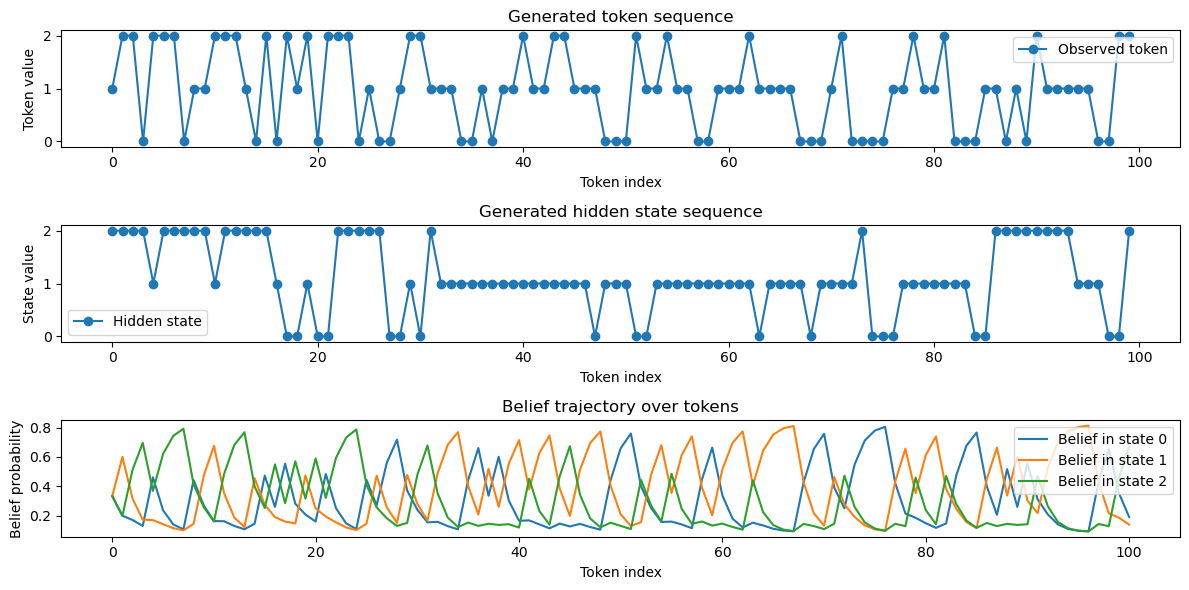

In [35]:
def plot_belief_history(tokens, states, beliefs, l_plot=100):
    """Plot tokens, hidden states, and belief components for the first l_plot steps."""
    n_tokens = min(l_plot, len(tokens))
    n_states = min(l_plot, len(states))

    fig, axes = plt.subplots(3, 1, figsize=(12, 6))

    axes[0].plot(np.arange(n_tokens), tokens[:n_tokens], marker="o", linestyle="-", label="Observed token")
    axes[0].set_xlabel("Token index")
    axes[0].set_ylabel("Token value")
    axes[0].set_title("Generated token sequence")
    axes[0].set_yticks([0, 1, 2])
    axes[0].legend()

    axes[1].plot(np.arange(n_states), states[:n_states], marker="o", linestyle="-", label="Hidden state")
    axes[1].set_xlabel("Token index")
    axes[1].set_ylabel("State value")
    axes[1].set_title("Generated hidden state sequence")
    axes[1].set_yticks([0, 1, 2])
    axes[1].legend()

    axes[2].set_prop_cycle(None)
    for i in range(beliefs.shape[1]):
        axes[2].plot(np.arange(n_tokens + 1), beliefs[: n_tokens + 1, i], label=f"Belief in state {i}")
    axes[2].set_xlabel("Token index")
    axes[2].set_ylabel("Belief probability")
    axes[2].set_title("Belief trajectory over tokens")
    axes[2].legend()

    plt.tight_layout()
    return fig, axes

fig, axes = plot_belief_history(tokens, states, beliefs)

I've plotted the tokens (observations), hidden states, and beliefs for the first 100 tokens in the sequence. We can see that the beliefs fluctuate with the observations.

Let's think about the set of possible beliefs we could have. Only a limited set of belief states can be attained. Firstly, each probability is constrained to have a value betweek 0 and 1, so we must be constrained within a space bounded by 0 and 1 in three dimensions. Next, we also notice that if we fix two of the probabilities, the other is uniquely determined, because they all must sum to one. Therefore, we will be restricted to a 2-dimensional subspace in the three dimensional probability space. This subspace will be shpaed like a triangle, otherwise called a 2-simplex. Why a triangle? We can think of this intuitively. As we approach probability 1 for any one of the states, we make the other probabilities smaller. The highest possible probability one could have is one, in which case the others must be zero. These are the vertices of the triangle. The beliefs may live within this triangle. However, the structure of the transition matrix is going to restrict the ones we can see for any given Mess3 process. This we'll call the belief structure. I'll plot that for the Mess3 process I just created.

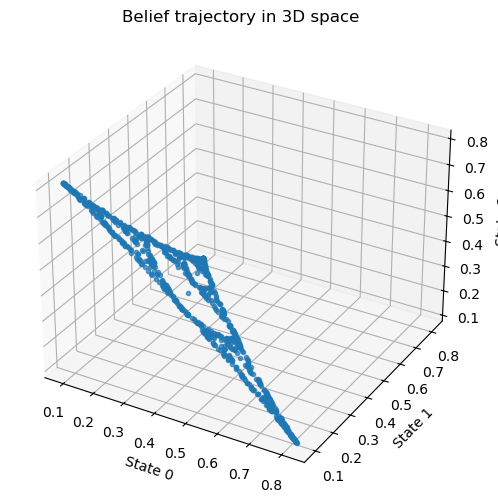

In [36]:
# Make 3D plot to show belief trajectory in 3D space
# We should be able tp see the probability vectors lying on a 2D simplex subspace

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot belief trajectory in 3D
ax.plot(beliefs[:, 0], beliefs[:, 1], beliefs[:, 2], marker='.', linestyle='None', alpha=0.7)
ax.set_xlabel('State 0')
ax.set_ylabel('State 1')
ax.set_zlabel('State 2')
ax.set_title('Belief trajectory in 3D space')

plt.show()

I've just plotted all of the belief vectors over the entire belief trajectory in a three dimensional probability space. We can see that the belief vectors live in a 2D space within this 3D space, as we predicted. Now, let's project his onto a 2D space so we can see the fine structure more clearly.

To do this, we'll need to create a 3 x 2 matrix for the projection. The columns of this matrix will be the vertices of the simplex. This works because each point in the space can be expressed as a convex combination of the vertices. We'll choose to mat this to an equilateral traingle by making all the vertices equidistant from each other.

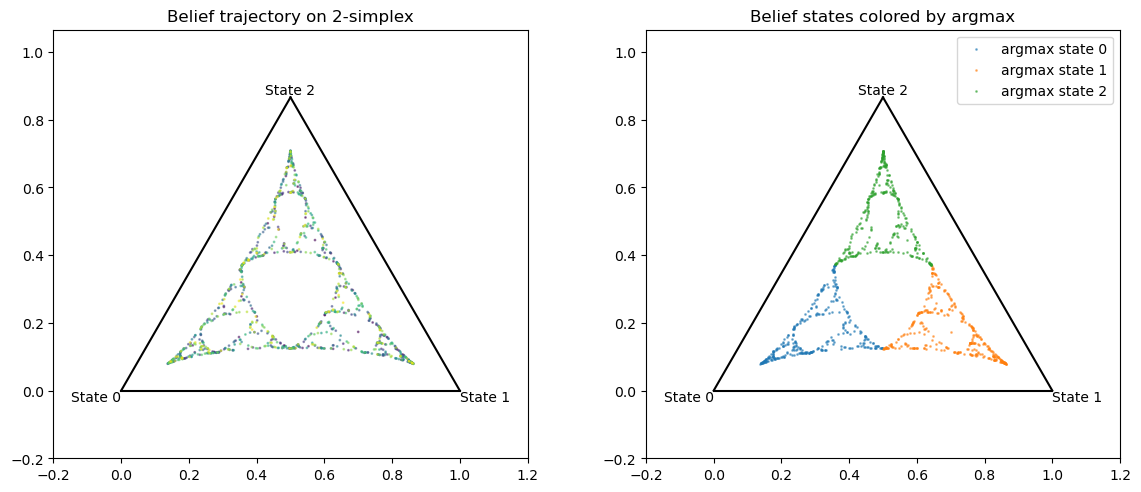

In [37]:
def plot_belief_simplex(beliefs):
    """Plot belief trajectories on a 2-simplex; beliefs shape == (T+1, 3)."""
    corners = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, np.sqrt(3) / 2]])
    coords_2d = beliefs @ corners

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Belief geometry (all points, colored by time index)
    axes[0].scatter(
        coords_2d[1:, 0],
        coords_2d[1:, 1],
        c=np.arange(len(coords_2d) - 1),
        cmap="viridis",
        s=1,
        alpha=0.5,
    )
    axes[0].set_title("Belief trajectory on 2-simplex")
    axes[0].set_aspect("equal")

    # Belief geometry colored by current argmax state
    dominant_state = np.argmax(beliefs[1:], axis=1)
    for state in range(3):
        mask = dominant_state == state
        if np.any(mask):
            axes[1].scatter(
                coords_2d[1:][mask, 0],
                coords_2d[1:][mask, 1],
                s=1,
                alpha=0.5,
                label=f"argmax state {state}",
            )
    axes[1].legend()
    axes[1].set_title("Belief states colored by argmax")
    axes[1].set_aspect("equal")

    # Shared simplex edges + labels
    for ax in axes:
        for i in range(3):
            j = (i + 1) % 3
            ax.plot(corners[[i, j], 0], corners[[i, j], 1], "k-")
        ax.text(corners[0, 0], corners[0, 1], "State 0", ha="right", va="top")
        ax.text(corners[1, 0], corners[1, 1], "State 1", ha="left", va="top")
        ax.text(corners[2, 0], corners[2, 1], "State 2", ha="center", va="bottom")
        ax.set_xlim(-0.2, 1.2)
        ax.set_ylim(-0.2, np.sqrt(3) / 2 + 0.2)

    plt.tight_layout()
    return fig, axes

fig, axes = plot_belief_simplex(beliefs)

So now we can see that the belief vectors occupy a subset of possible positions in the simplex. We can see that it has a fractal-like structure (see Marzan et al. (2017)). This structure depends on the transition matrix which induces a set of more likely state transitions.

On the right side, I've colored the dots to correspond to the most likely state under that belief.

## Extreme Cases

To better understand how the transition matrix enforces the structure, it can be helpful to look at the extrema of the transition matrices.

In [42]:
alpha = 0
x = 0

proc = Mess3(alpha=alpha, x=x)
    
rng = np.random.default_rng(42)
tokens, states = proc.generate_sequence(1000, rng=rng)
beliefs = proc.belief_trajectory(tokens)

print(f"Token frequencies: {np.bincount(tokens, minlength=3) / len(tokens)}")
print(f"State frequencies: {np.bincount(states, minlength=3) / len(states)}")
print("Transition matrices (T):")
print(proc.T)
print("Net transition matrix (T_net):")
print(proc.T_net)

Token frequencies: [0.504 0.496 0.   ]
State frequencies: [0. 0. 1.]
Transition matrices (T):
[[[0.  0.  0. ]
  [0.  0.5 0. ]
  [0.  0.  0.5]]

 [[0.5 0.  0. ]
  [0.  0.  0. ]
  [0.  0.  0.5]]

 [[0.5 0.  0. ]
  [0.  0.5 0. ]
  [0.  0.  0. ]]]
Net transition matrix (T_net):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


This is a process for which there is no possibility of transitioning between states. For a given state, the probability of emision is split equally between two of the three tokens.

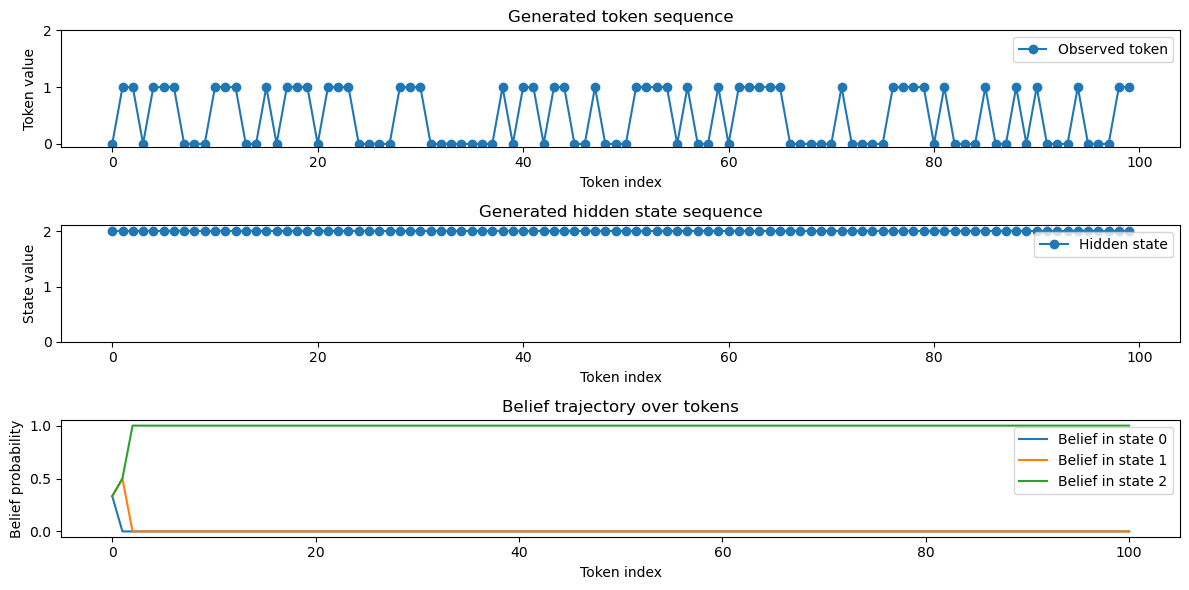

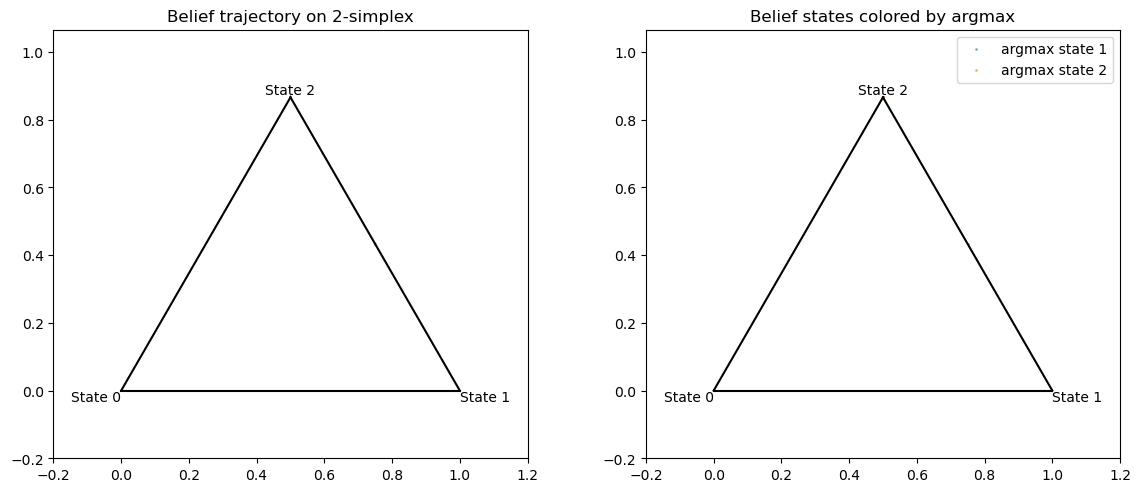

In [43]:
fig, axes = plot_belief_history(tokens, states, beliefs)

fig, axes = plot_belief_simplex(beliefs)

In this case the beliefs converge quickly to the correct state. That's because only one state permits the observation of a 0 and 1. After observed a 0 and a 1 token, we can be absolutely certain we are in state 2. So the belief geometry will be quite boring in this case.

In [41]:
alpha = 1
x = 0

proc = Mess3(alpha=alpha, x=x)
    
rng = np.random.default_rng(42)
tokens, states = proc.generate_sequence(1000, rng=rng)
beliefs = proc.belief_trajectory(tokens)

print(f"Token frequencies: {np.bincount(tokens, minlength=3) / len(tokens)}")
print(f"State frequencies: {np.bincount(states, minlength=3) / len(states)}")
print("Transition matrices (T):")
print(proc.T)
print("Net transition matrix (T_net):")
print(proc.T_net)

Token frequencies: [0. 0. 1.]
State frequencies: [0. 0. 1.]
Transition matrices (T):
[[[1. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 1. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 1.]]]
Net transition matrix (T_net):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In this case, we still never leave the state we're in, and now there is only one possible observation per state. Again we shuld get pretty boring geometry.

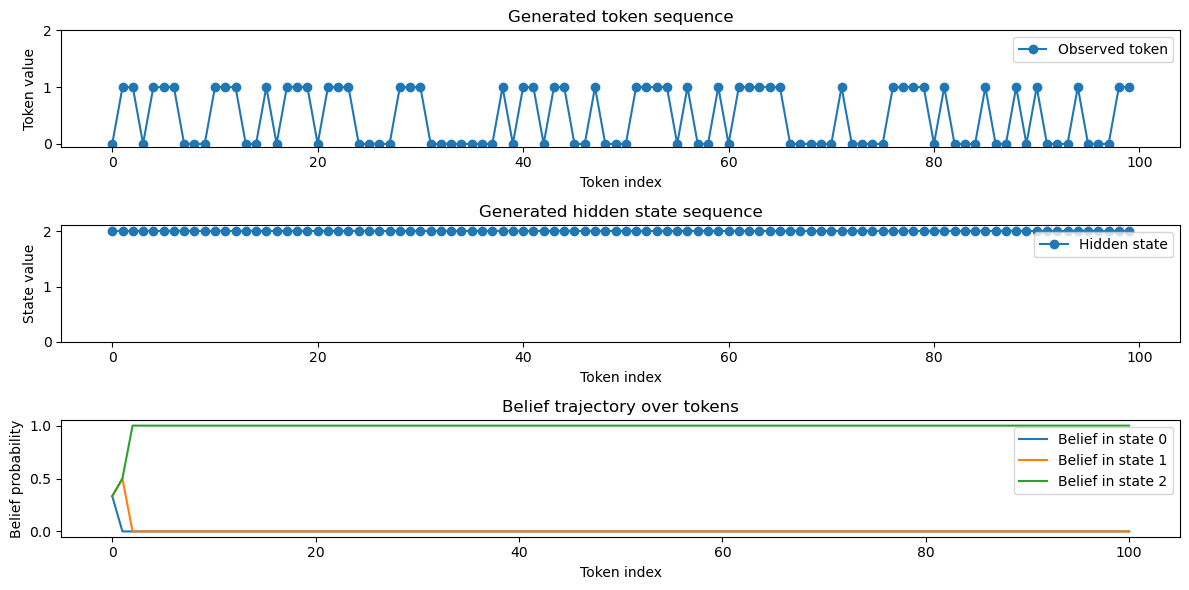

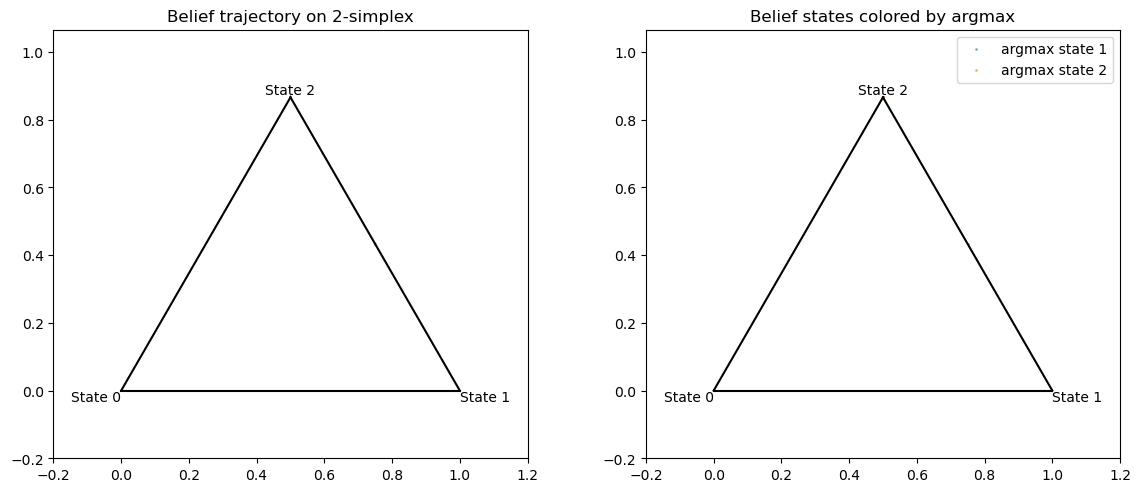

In [44]:
fig, axes = plot_belief_history(tokens, states, beliefs)

fig, axes = plot_belief_simplex(beliefs)

In [45]:
alpha = 0
x = 0.5

proc = Mess3(alpha=alpha, x=x)
    
rng = np.random.default_rng(42)
tokens, states = proc.generate_sequence(1000, rng=rng)
beliefs = proc.belief_trajectory(tokens)

print(f"Token frequencies: {np.bincount(tokens, minlength=3) / len(tokens)}")
print(f"State frequencies: {np.bincount(states, minlength=3) / len(states)}")
print("Transition matrices (T):")
print(proc.T)
print("Net transition matrix (T_net):")
print(proc.T_net)

Token frequencies: [0.35  0.304 0.346]
State frequencies: [0.33866134 0.32967033 0.33166833]
Transition matrices (T):
[[[0.   0.25 0.25]
  [0.   0.   0.25]
  [0.   0.25 0.  ]]

 [[0.   0.   0.25]
  [0.25 0.   0.25]
  [0.25 0.   0.  ]]

 [[0.   0.25 0.  ]
  [0.25 0.   0.  ]
  [0.25 0.25 0.  ]]]
Net transition matrix (T_net):
[[0.  0.5 0.5]
 [0.5 0.  0.5]
 [0.5 0.5 0. ]]


Now we will always transition states and never stay in the same state between tokens.

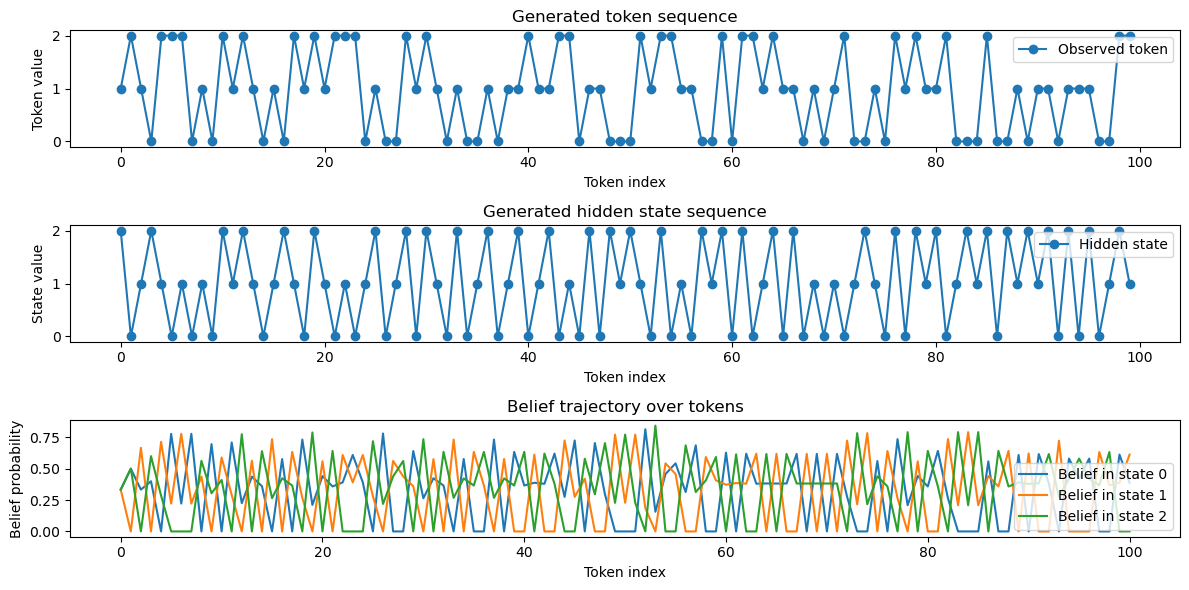

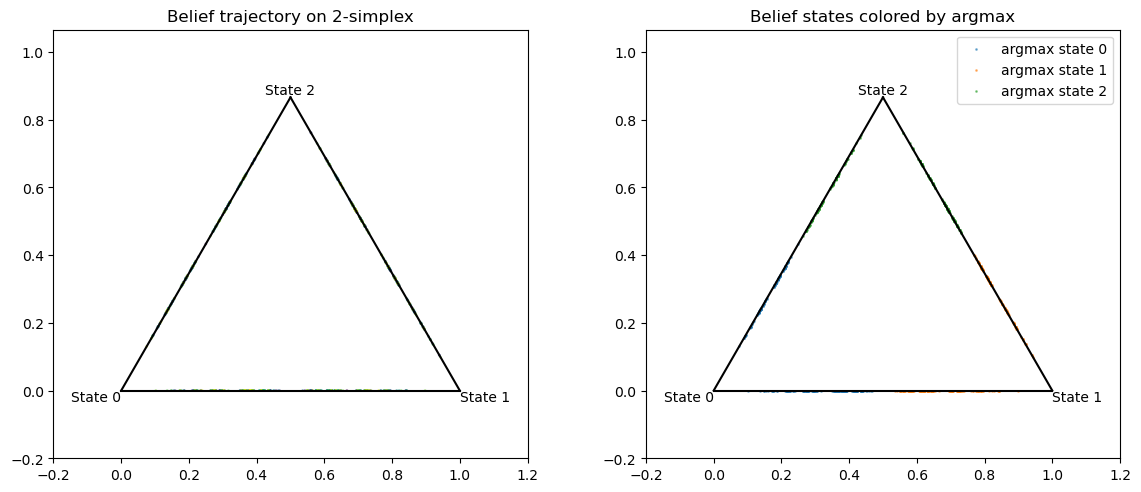

In [46]:
fig, axes = plot_belief_history(tokens, states, beliefs)

fig, axes = plot_belief_simplex(beliefs)

If we zoom in, we can see that all of the belief vectors live on the edges of the triangle, because the observation permit only two possible states at a time.

In [47]:
alpha = 1
x = 0.5

proc = Mess3(alpha=alpha, x=x)
    
rng = np.random.default_rng(42)
tokens, states = proc.generate_sequence(1000, rng=rng)
beliefs = proc.belief_trajectory(tokens)

print(f"Token frequencies: {np.bincount(tokens, minlength=3) / len(tokens)}")
print(f"State frequencies: {np.bincount(states, minlength=3) / len(states)}")
print("Transition matrices (T):")
print(proc.T)
print("Net transition matrix (T_net):")
print(proc.T_net)

Token frequencies: [0.341 0.325 0.334]
State frequencies: [0.34065934 0.32467532 0.33466533]
Transition matrices (T):
[[[0.  0.  0. ]
  [0.5 0.  0. ]
  [0.5 0.  0. ]]

 [[0.  0.5 0. ]
  [0.  0.  0. ]
  [0.  0.5 0. ]]

 [[0.  0.  0.5]
  [0.  0.  0.5]
  [0.  0.  0. ]]]
Net transition matrix (T_net):
[[0.  0.5 0.5]
 [0.5 0.  0.5]
 [0.5 0.5 0. ]]


Now we transition on every token, but each state permits only one possible observation. Once again, we should get boring structure fixed to the vertices.

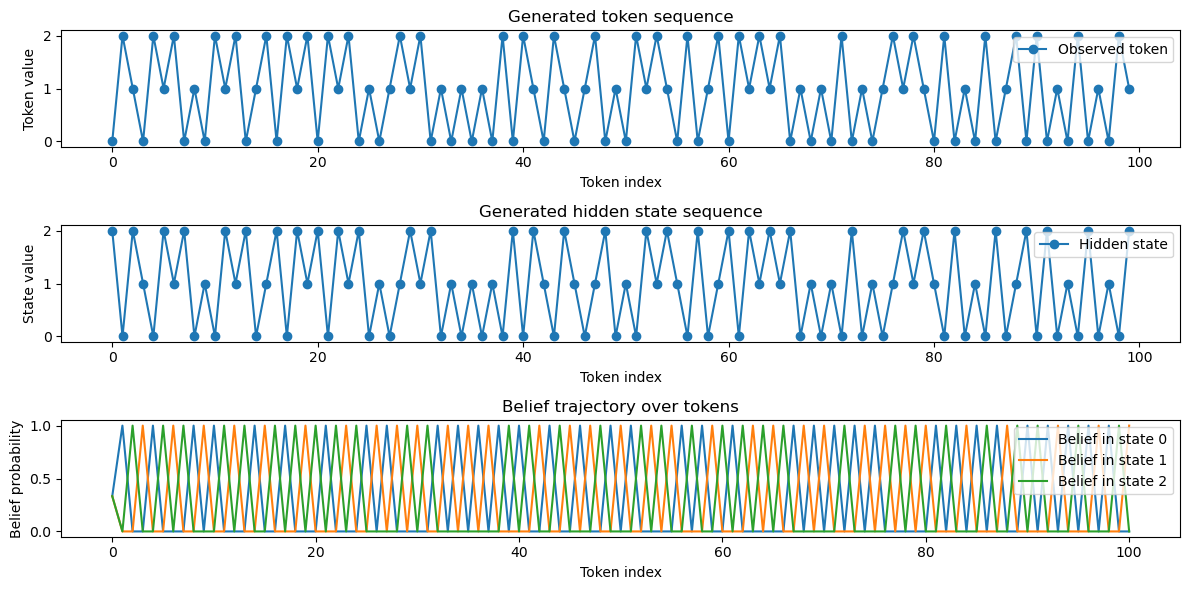

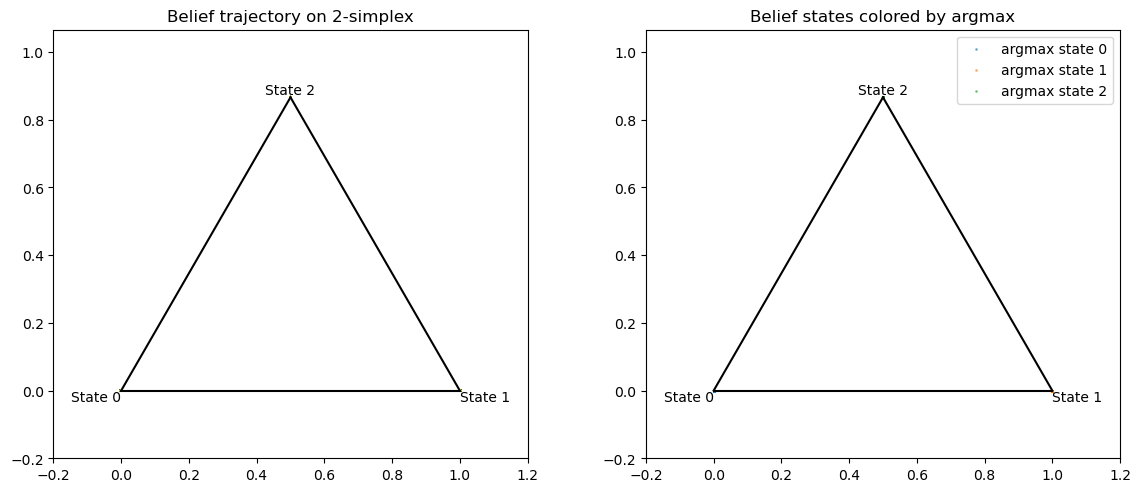

In [48]:
fig, axes = plot_belief_history(tokens, states, beliefs)

fig, axes = plot_belief_simplex(beliefs)

## Sweeping over parameters

How does the belief structure vary with the transtion matrix parameters?

We can see from the net transition matrix that $x$ determines how much probability the diagonal gets versus the off diagonal. $\alpha$ on the other hand sets the relative weights of the belief transition matrices. $\alpha$ scales the probability of the influence of the current state, while $\beta$ divides between the other two states the remaining weight. Therefore, as $x$ increases, we can pretty straightforwarly predict more transitions between states. This should manifest as the belief geometry navigating away from the vertices. Meanwhile, $\alpha$ should change the distribution of the observations for given states.

In [55]:
# Run grid search over (alpha, x) and plot belief geometry for each setting
alphas = [0.1, 0.4, 0.5, 0.6, 0.9]
xs = [0.05, 0.15, 0.25, 0.35, 0.45]
len_seq = 1000

token_mat = np.zeros((len(alphas), len(xs), len_seq), dtype=object)
state_mat = np.zeros((len(alphas), len(xs), len_seq+1), dtype=object)
belief_mat = np.zeros((len(alphas), len(xs), len_seq+1, 3), dtype=object)

for i, alpha in enumerate(alphas):
    for j, x in enumerate(xs):
        proc = Mess3(alpha=alpha, x=x)
        rng = np.random.default_rng(42)
        tokens, states = proc.generate_sequence(len_seq, rng=rng)
        beliefs = proc.belief_trajectory(tokens)
        
        token_mat[i, j, :] = tokens
        state_mat[i, j, :] = states
        belief_mat[i, j, :, :] = beliefs

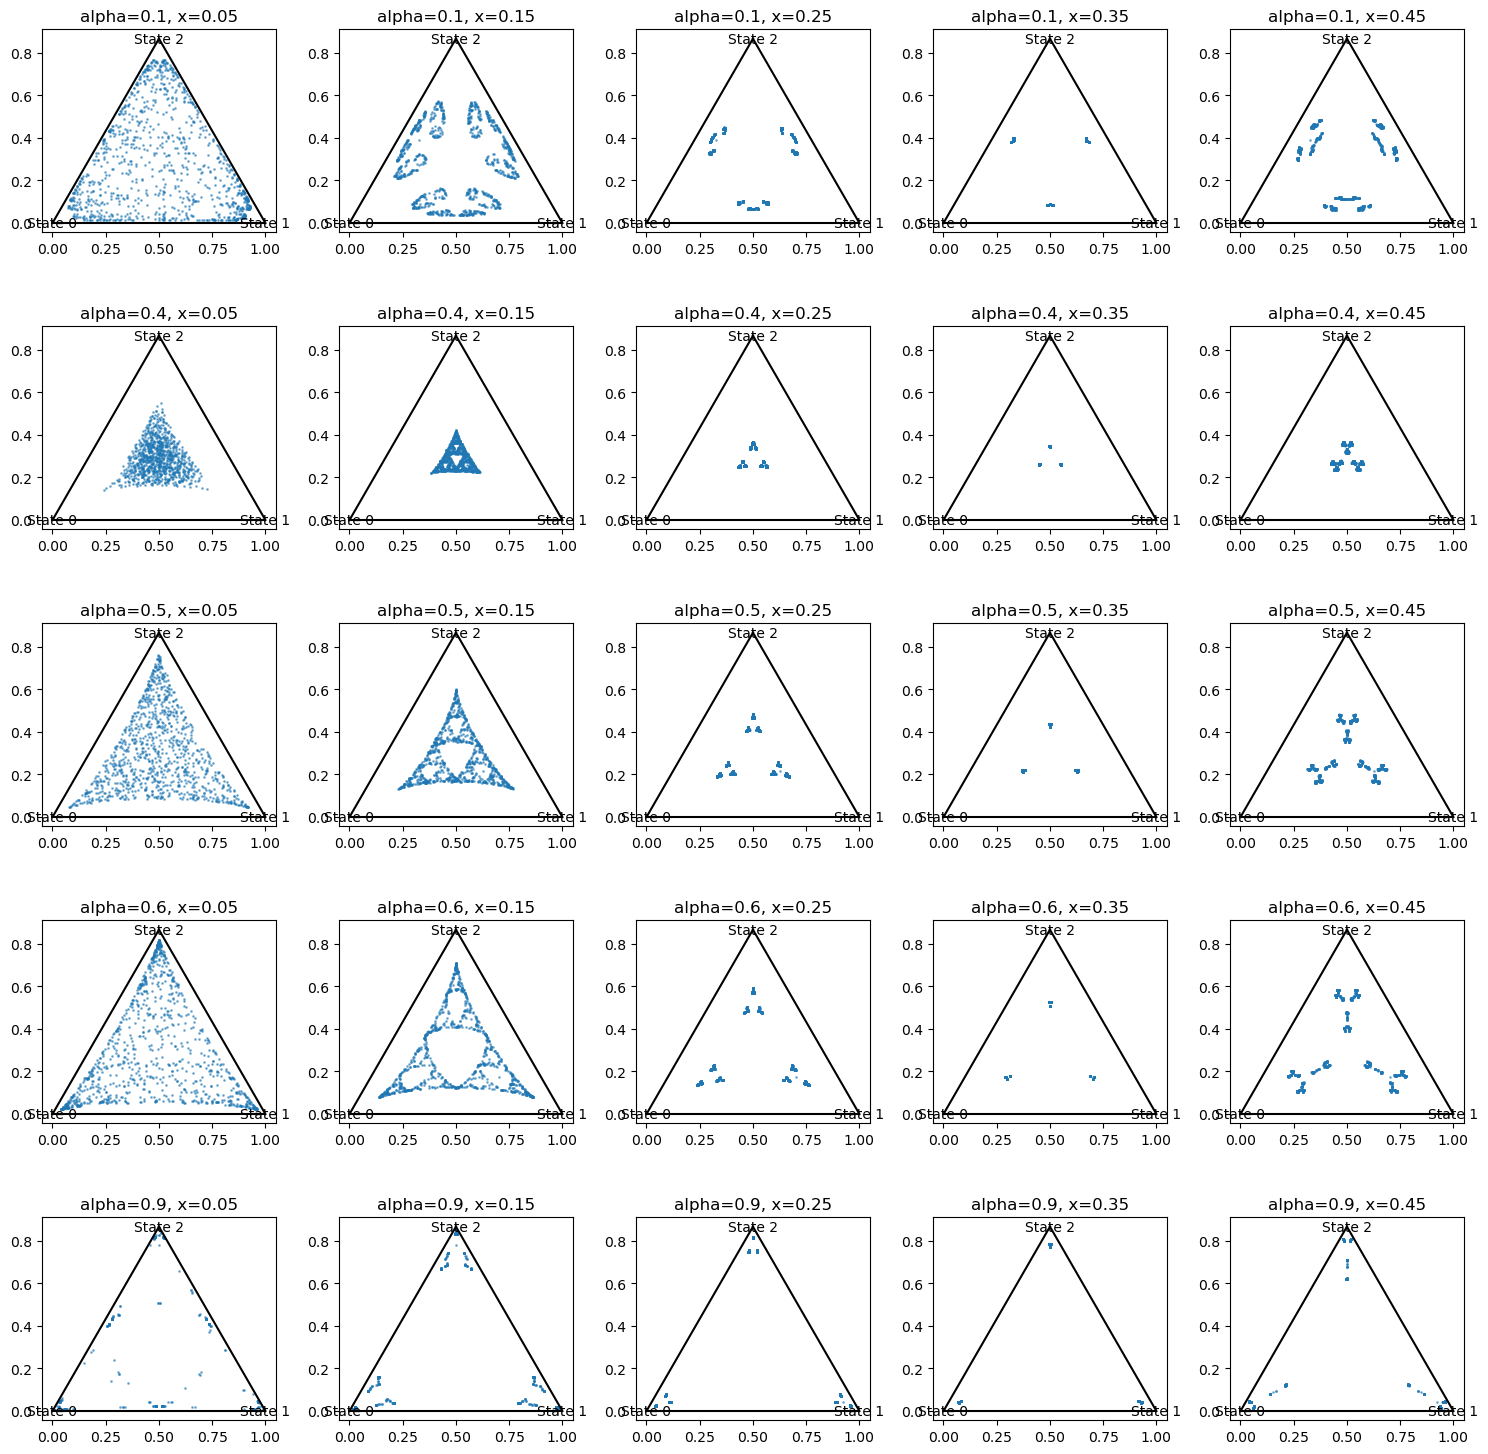

In [56]:
# Plot belief geometry as grid of subplots for each (alpha, x) setting
fig, axes = plt.subplots(len(alphas), len(xs), figsize=(15, 15))
for i, alpha in enumerate(alphas):
    for j, x in enumerate(xs):
        beliefs = belief_mat[i, j]
        coords_2d = beliefs @ np.array([[0.0, 0.0], [1.0, 0.0], [0.5, np.sqrt(3) / 2]])
        axes[i, j].scatter(coords_2d[1:, 0], coords_2d[1:, 1], s=1, alpha=0.5)
        axes[i, j].set_title(f"alpha={alpha}, x={x}")
        axes[i, j].set_aspect("equal")
        # Add simplex edges
        corners = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, np.sqrt(3) / 2]])
        for k in range(3):
            l = (k + 1) % 3
            axes[i, j].plot(corners[[k, l], 0], corners[[k, l], 1], "k-")
            axes[i, j].text(corners[k, 0], corners[k, 1], f"State {k}", ha="center", va="center")
plt.tight_layout()